In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

# Load Sudoku image

In [69]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import matplotlib.patches as patches

In [70]:
def load_sudoku_image(image_path):
    # Load the Sudoku image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Apply preprocessing (Thresholding)
    _, thresh = cv2.threshold(image, 150, 255, cv2.THRESH_BINARY_INV)
    
    # Find contours to detect grid
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Sort contours by area and select the largest (assuming it's the grid)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    # Set default width and height (in case grid detection fails)
    width, height = 450, 450  
    
    # Get bounding box of the grid
    sudoku_grid = None
    for contour in contours:
        approx = cv2.approxPolyDP(contour, 0.02 * cv2.arcLength(contour, True), True)
        if len(approx) == 4:  # Looking for a quadrilateral (Sudoku Grid)
            sudoku_grid = approx
            break
    
    # Warp perspective if necessary (To get a straight grid)
    if sudoku_grid is not None:
        pts = np.array([sudoku_grid[i][0] for i in range(4)], dtype="float32")
    
        # Sort the points in the correct order
        def order_points(pts):
            rect = np.zeros((4, 2), dtype="float32")
            s = pts.sum(axis=1)  # Sum of x and y coordinates
            diff = np.diff(pts, axis=1)  # Difference (y - x)
    
            rect[0] = pts[np.argmin(s)]  # Top-left
            rect[2] = pts[np.argmax(s)]  # Bottom-right
            rect[1] = pts[np.argmin(diff)]  # Top-right
            rect[3] = pts[np.argmax(diff)]  # Bottom-left
    
            return rect
    
        ordered_pts = order_points(pts)  # Ensure correct order
        pts_dst = np.array([[0, 0], [width, 0], [width, height], [0, height]], dtype="float32")
    
        # Compute transformation matrix
        M = cv2.getPerspectiveTransform(ordered_pts, pts_dst)
        image = cv2.warpPerspective(image, M, (width, height))
    else:
        image = cv2.resize(image, (width, height))  # Resize image instead if grid detection fails
    
    plt.figure(figsize=(6,6))
    plt.imshow(image, cmap='gray')
    plt.axis("off")
    plt.show()

    return image

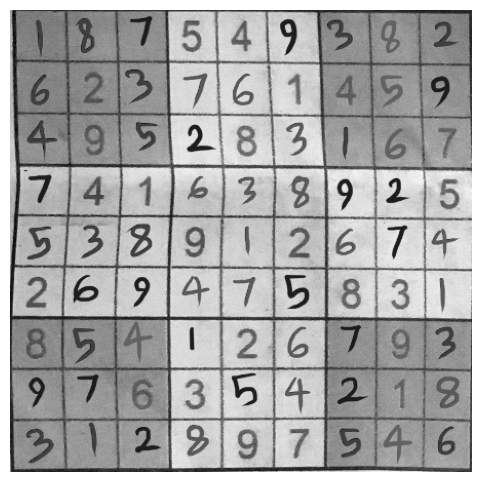

In [71]:
image = load_sudoku_image("sudoku/1.png")

In [9]:
# result = cv2.adaptiveThreshold(image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
# kernel = np.ones((2,2), np.uint8)
# result = cv2.morphologyEx(result, cv2.MORPH_CLOSE, kernel)

# result = cv2.adaptiveThreshold(result, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)
# kernel = np.ones((3, 3), np.uint8)

# grid_mask = None

# for width in range(1, 3, 1):
#     for length in range(8, 50, 10):
#         h_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (length, width))
#         horizontal = cv2.morphologyEx(result, cv2.MORPH_OPEN, h_kernel, iterations=5)
#         v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (width, length))
#         vertical = cv2.morphologyEx(result, cv2.MORPH_OPEN, v_kernel, iterations=5)
#         if grid_mask is None:
#             grid_mask = cv2.bitwise_or(horizontal, vertical)
#         else:
#             grid_mask = cv2.bitwise_or(grid_mask, cv2.bitwise_or(horizontal, vertical))

# for width in range(1, 5, 1):
#     for length in range(1, 5, 1):
#         kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (length, width))
#         removed_dots = cv2.morphologyEx(result, cv2.MORPH_OPEN, v_kernel, iterations=5)
#         grid_mask = cv2.bitwise_or(grid_mask, removed_dots)

# grid_mask_inv = cv2.bitwise_not(grid_mask)
# result = cv2.bitwise_and(result, grid_mask_inv)
# result = cv2.bitwise_not(result)

# plt.figure(figsize=(6,6))
# plt.imshow(result, cmap='gray')
# plt.axis("off")
# plt.show()

# Read grids using Tesseract

In [37]:
# !pip install pytesseract

In [77]:
import pytesseract

# download and install from https://github.com/tesseract-ocr/tesseract/releases/download/5.5.0/tesseract-ocr-w64-setup-5.5.0.20241111.exe
# Set Tesseract path if not in system PATH
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [79]:
actual_grid = [
    [1, 8, 7, 5, 4, 9, 3, 8, 2],
    [6, 2, 3, 7, 6, 1, 4, 5, 9],
    [4, 9, 5, 2, 8, 3, 1, 6, 7],
    [7, 4, 1, 6, 3, 8, 9, 2, 5],
    [5, 3, 8, 9, 1, 2, 6, 7, 4],
    [2, 6, 9, 4, 7, 5, 8, 3, 1],
    [8, 5, 4, 1, 2, 6, 7, 9, 3],
    [9, 7, 6, 3, 5, 4, 2, 1, 8],
    [3, 1, 2, 8, 9, 7, 5, 4, 6],
]

In [80]:
width, height = image.shape

cell_size = width // 9
sudoku_numbers = []
undetected_cnt = 0
incorrect_cnt = 0

cells = []

def isdigit(number):
    return number.isdigit() and len(number) == 1

for row in range(9):
    row_numbers = []
    for col in range(9):
        x, y = col * cell_size, row * cell_size
        cell = image[y:y + cell_size, x:x + cell_size]
        
        cwidth, cheight = cell.shape
        cell = cell[int(cwidth*0.1):int(cwidth*0.95), int(cheight*0.2):int(cheight*0.9)]
        
        cell = cv2.GaussianBlur(cell, (3,3), 0)
        _, cell = cv2.threshold(cell, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        
        kernel = np.ones((2, 2), np.uint8)
        cell = cv2.morphologyEx(cell, cv2.MORPH_OPEN, kernel)

        custom_config = r'--oem 3 --psm 6 -c tessedit_char_whitelist=123456789'
        number = pytesseract.image_to_string(cell, config=custom_config, lang="eng").strip()

        if not isdigit(number):
            cell = cv2.morphologyEx(cell, cv2.MORPH_CLOSE, kernel)
            number = pytesseract.image_to_string(cell, config=custom_config, lang="eng").strip()

        if not isdigit(number):
            cell = cv2.bitwise_not(cell)
            cell = cv2.dilate(cell, kernel, iterations=1)
            cell = cv2.bitwise_not(cell)
            number = pytesseract.image_to_string(cell, config=custom_config, lang="eng").strip()

        incorrect = isdigit(number) and str(actual_grid[row][col]) != number
        cells += [{'img': cell, 'undetected': not isdigit(number), 'number': number, 'incorrect': incorrect}]

        if not isdigit(number):
            undetected_cnt += 1
        if incorrect:
            incorrect_cnt += 1

        # Store the recognized number
        row_numbers.append(number if isdigit(number) else "_")
    
    sudoku_numbers.append(row_numbers)

print(f"undetected = {undetected_cnt}")
print(f"incorrect = {incorrect_cnt}")


undetected = 11
incorrect = 6


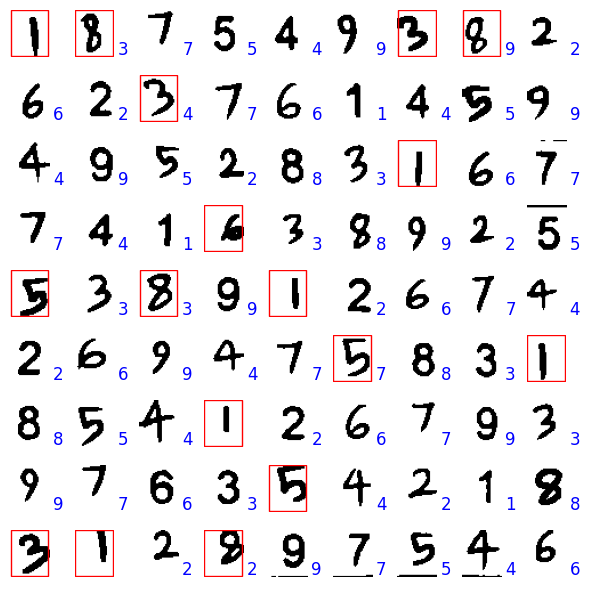

In [81]:
fig, axes = plt.subplots(9, 9, figsize=(6, 6)) 
for ax, img in zip(axes.ravel(), cells):
    ax.imshow(img['img'], cmap='gray')
    ax.axis('off')
    height, width = img['img'].shape
    if img['undetected'] or img['incorrect']:
        rect = patches.Rectangle(
            (0, 0), width-2, height-2, linewidth=1, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
    if not img['undetected']:
        ax.text(
            height, width,
            img['number'],
            color='blue', fontsize=12, fontweight='normal',
            ha='center', va='center', bbox=dict(facecolor='white', alpha=0, edgecolor='none')
        )

plt.tight_layout()
plt.show()

# Read grids using Resnet

In [10]:
import mynnlib
from mynnlib import *

## Train a model for digits

In [137]:
# for index, cell in enumerate(cells):
#     cv2.imwrite(f"sudoku/train/img_{index}.jpg", cell['img'])

In [62]:
training_params = [
    { "idx": 1, "robustness": 0.2, "break_at_val_acc_diff": 0.02},
    { "idx": 2, "robustness": 0.5, "break_at_val_acc_diff": 0.01},
    { "idx": 3, "robustness": 0.6, "break_at_val_acc_diff": 0.005},
    { "idx": 4, "robustness": 0.8, "break_at_val_acc_diff": -0.000001},
    { "idx": 5, "robustness": 1.0, "break_at_val_acc_diff": -0.000001},
    { "idx": 6, "robustness": 1.0, "break_at_val_acc_diff": -0.000001},
    { "idx": 7, "robustness": 1.5, "break_at_val_acc_diff": -0.000001},
    { "idx": 8, "robustness": 1.5, "break_at_val_acc_diff": -0.000001},
    { "idx": 9, "robustness": 2.0, "break_at_val_acc_diff": -0.000001},
    { "idx": 10, "robustness": 2.0, "break_at_val_acc_diff": -0.000001}
]
start_time = time.time()
print("Started at:", datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
for param in training_params:
    print(f"Phase {param["idx"]}:")
    if param["idx"] == 1:
        model_data = init_model_for_training(f'sudoku/train', f'sudoku/train', 
                                             batch_size=64, arch="resnet34", image_size=224, robustness=param["robustness"],
                                             lr=1e-4, weight_decay=1e-4, silent=True)
    else:
        model_data = prepare_for_retraining(model_data, f'sudoku/train', f'sudoku/train', 
                                            batch_size=64, image_size=224, robustness=param["robustness"], silent=True)
    train(model_data, 10, f"sudoku/checkpoint.pth", 
          break_at_val_acc_diff=param["break_at_val_acc_diff"])
    print(f"Current time: {datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")} | Total elapsed time: {datetime.timedelta(seconds=(time.time() - start_time))}")

Started at: 2025-03-29 11:59:41
Phase 1:
Epoch    0 /    9  | Train Loss: 1.9592 Acc: 0.3484  | Val Loss: 1.7679 Acc: 0.4774  | Elapsed time: 0:00:01.200294
Epoch    1 /    9  | Train Loss: 0.8319 Acc: 0.9419  | Val Loss: 0.9714 Acc: 0.9032  | Elapsed time: 0:00:02.471507
Epoch    2 /    9  | Train Loss: 0.3061 Acc: 1.0000  | Val Loss: 0.2900 Acc: 0.9871  | Elapsed time: 0:00:03.707989
Epoch    3 /    9  | Train Loss: 0.1215 Acc: 1.0000  | Val Loss: 0.0663 Acc: 1.0000  | Elapsed time: 0:00:04.945794
Current time: 2025-03-29 11:59:47 | Total elapsed time: 0:00:05.485174
Phase 2:
Epoch    0 /    9  | Train Loss: 1.3348 Acc: 0.6065  | Val Loss: 0.0387 Acc: 0.9935  | Elapsed time: 0:00:01.064775
Epoch    1 /    9  | Train Loss: 1.2411 Acc: 0.5355  | Val Loss: 0.0462 Acc: 0.9871  | Elapsed time: 0:00:02.392362
Current time: 2025-03-29 11:59:50 | Total elapsed time: 0:00:08.156644
Phase 3:
Epoch    0 /    9  | Train Loss: 0.8625 Acc: 0.7161  | Val Loss: 0.0383 Acc: 0.9871  | Elapsed time: 0:

In [63]:
model_data = torch.load(f"sudoku/checkpoint.pth", weights_only=False)

In [64]:
def resnet_image_to_digit(digit_image, threshold):
    model_data['model'].eval()
    digit_image = model_data['transform']['val'](digit_image).unsqueeze(0).to(model_data['device'])
    with torch.no_grad():
        outputs = model_data['model'](digit_image)
        probabilities = F.softmax(outputs, dim=1)
        top_probs, top_indices = torch.topk(probabilities, 1)
        if top_probs[0].item() < threshold:
            return ""
        # print(top_probs[0].item())
    return f"{top_indices[0].item() + 1}"

def resnet_cv2_grey_image_to_digit(digit_image, threshold=0.5):
    digit_image = cv2.cvtColor(digit_image, cv2.COLOR_GRAY2BGR)
    digit_image = resnet_image_to_digit(Image.fromarray(digit_image), threshold)
    return digit_image

sudoku/train/6/img_65.jpg predicted as 


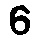

In [66]:
# test
from IPython.display import display

for digit in os.listdir("sudoku/train"):
    for file in os.listdir(f"sudoku/train/{digit}"):
        pred = resnet_image_to_digit(Image.open(f"sudoku/train/{digit}/{file}").convert("RGB"), 0.6)
        if pred != f"{digit}":
            print(f"sudoku/train/{digit}/{file} predicted as {pred}")
            display(Image.open(f"sudoku/train/{digit}/{file}"))

## Use the model on the sudoku

In [89]:
def read_sudoku_from_image(image, actual_grid, threshold):
    width, height = image.shape
    
    cell_size = width // 9
    sudoku_numbers = []
    undetected_cnt = 0
    incorrect_cnt = 0
    
    cells = []
    
    def isdigit(number):
        return number.isdigit() and len(number) == 1
    
    for row in range(9):
        row_numbers = []
        for col in range(9):
            x, y = col * cell_size, row * cell_size
            cell = image[y:y + cell_size, x:x + cell_size]
            
            cwidth, cheight = cell.shape
            cell = cell[int(cwidth*0.1):int(cwidth*0.95), int(cheight*0.2):int(cheight*0.9)]
            
            cell = cv2.GaussianBlur(cell, (3,3), 0)
            _, cell = cv2.threshold(cell, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            
            kernel = np.ones((2, 2), np.uint8)
            cell = cv2.morphologyEx(cell, cv2.MORPH_OPEN, kernel)
    
            number = resnet_cv2_grey_image_to_digit(cell, threshold)
    
            incorrect = isdigit(number) and actual_grid and str(actual_grid[row][col]) != number
            cells += [{'img': cell, 'undetected': not isdigit(number), 'number': number, 'incorrect': incorrect}]
    
            if not isdigit(number):
                undetected_cnt += 1
            if incorrect:
                incorrect_cnt += 1
    
            # Store the recognized number
            row_numbers.append(number if isdigit(number) else "_")
        
        sudoku_numbers.append(row_numbers)
    
    print(f"undetected = {undetected_cnt}")
    if actual_grid:
        print(f"incorrect = {incorrect_cnt}")

    fig, axes = plt.subplots(9, 9, figsize=(6, 6)) 
    for ax, img in zip(axes.ravel(), cells):
        ax.imshow(img['img'], cmap='gray')
        ax.axis('off')
        height, width = img['img'].shape
        if img['undetected'] or img['incorrect']:
            rect = patches.Rectangle(
                (0, 0), width-2, height-2, linewidth=1, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)
        if not img['undetected']:
            ax.text(
                height, width,
                img['number'],
                color='blue', fontsize=12, fontweight='normal',
                ha='center', va='center', bbox=dict(facecolor='white', alpha=0, edgecolor='none')
            )
    
    plt.tight_layout()
    plt.show()

    return sudoku_numbers

undetected = 1
incorrect = 0


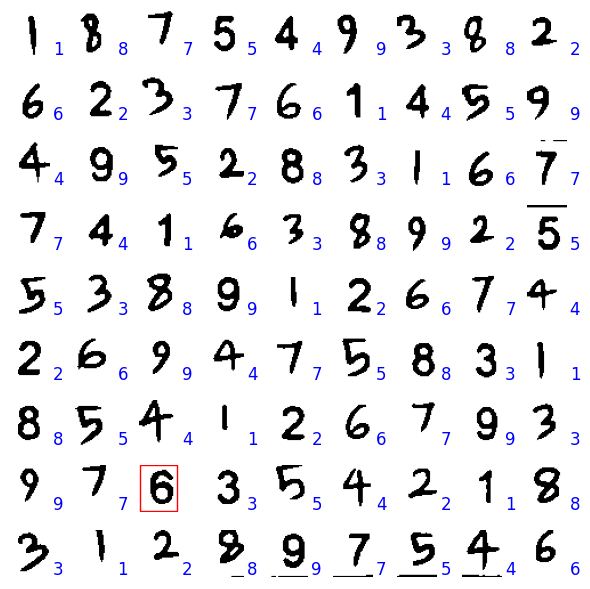

In [82]:
sudoku_numbers = read_sudoku_from_image(image, [
    [1, 8, 7, 5, 4, 9, 3, 8, 2],
    [6, 2, 3, 7, 6, 1, 4, 5, 9],
    [4, 9, 5, 2, 8, 3, 1, 6, 7],
    [7, 4, 1, 6, 3, 8, 9, 2, 5],
    [5, 3, 8, 9, 1, 2, 6, 7, 4],
    [2, 6, 9, 4, 7, 5, 8, 3, 1],
    [8, 5, 4, 1, 2, 6, 7, 9, 3],
    [9, 7, 6, 3, 5, 4, 2, 1, 8],
    [3, 1, 2, 8, 9, 7, 5, 4, 6],
], 0.6)

# Check sudoku validity

In [83]:
def is_valid_sudoku(grid):
    def is_unique(lst):
        """Check if a list contains unique numbers (ignoring '_')."""
        nums = [num for num in lst if num != "_"]
        return len(nums) == len(set(nums))  # Ensure no duplicates

    # Check rows
    for row in grid:
        if not is_unique(row):
            return False

    # Check columns
    for col in range(9):
        if not is_unique([grid[row][col] for row in range(9)]):
            return False

    # Check 3x3 subgrids
    for box_row in range(0, 9, 3):
        for box_col in range(0, 9, 3):
            subgrid = [
                grid[r][c]
                for r in range(box_row, box_row + 3)
                for c in range(box_col, box_col + 3)
            ]
            if not is_unique(subgrid):
                return False

    return True

for row in sudoku_numbers:
    print(" ".join(row))
    
# Verify Sudoku
print("\nValid Sudoku?" , is_valid_sudoku(sudoku_numbers))

1 8 7 5 4 9 3 8 2
6 2 3 7 6 1 4 5 9
4 9 5 2 8 3 1 6 7
7 4 1 6 3 8 9 2 5
5 3 8 9 1 2 6 7 4
2 6 9 4 7 5 8 3 1
8 5 4 1 2 6 7 9 3
9 7 _ 3 5 4 2 1 8
3 1 2 8 9 7 5 4 6

Valid Sudoku? False


------
# Run complete test on different images

## Test 1

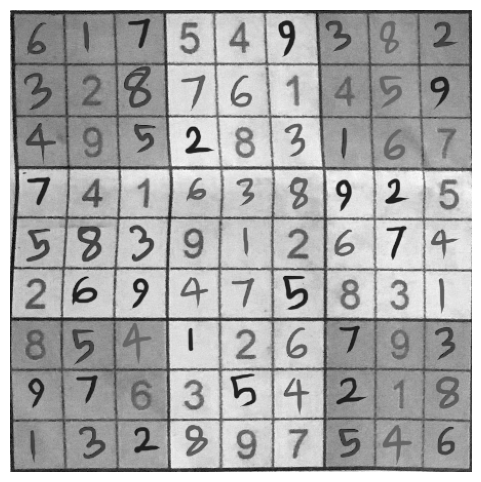

undetected = 5
incorrect = 0


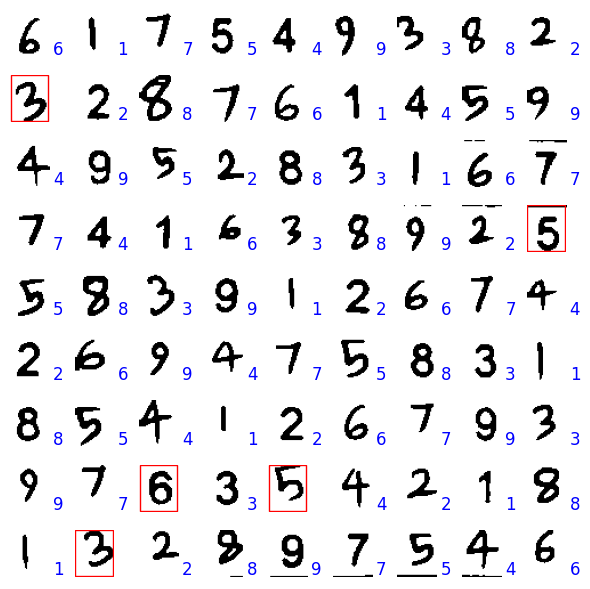

6 1 7 5 4 9 3 8 2
_ 2 8 7 6 1 4 5 9
4 9 5 2 8 3 1 6 7
7 4 1 6 3 8 9 2 _
5 8 3 9 1 2 6 7 4
2 6 9 4 7 5 8 3 1
8 5 4 1 2 6 7 9 3
9 7 _ 3 _ 4 2 1 8
1 _ 2 8 9 7 5 4 6

Valid Sudoku? True


In [85]:
image_test = load_sudoku_image("sudoku/2.png")
sudoku_numbers_test = read_sudoku_from_image(image_test, [
    [6, 1, 7, 5, 4, 9, 3, 8, 2],
    [3, 2, 8, 7, 6, 1, 4, 5, 9],
    [4, 9, 5, 2, 8, 3, 1, 6, 7],
    [7, 4, 1, 6, 3, 8, 9, 2, 5],
    [5, 8, 3, 9, 1, 2, 6, 7, 4],
    [2, 6, 9, 4, 7, 5, 8, 3, 1],
    [8, 5, 4, 1, 2, 6, 7, 9, 3],
    [9, 7, 6, 3, 5, 4, 2, 1, 8],
    [1, 3, 2, 8, 9, 7, 5, 4, 6],
], 0.75)
for row in sudoku_numbers_test:
    print(" ".join(row))
print("\nValid Sudoku?" , is_valid_sudoku(sudoku_numbers_test))

## Test 2

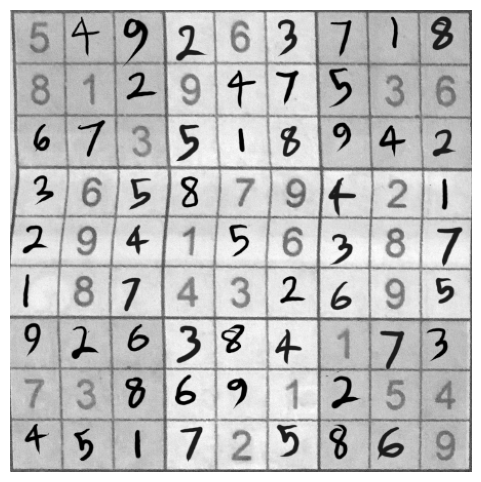

undetected = 17


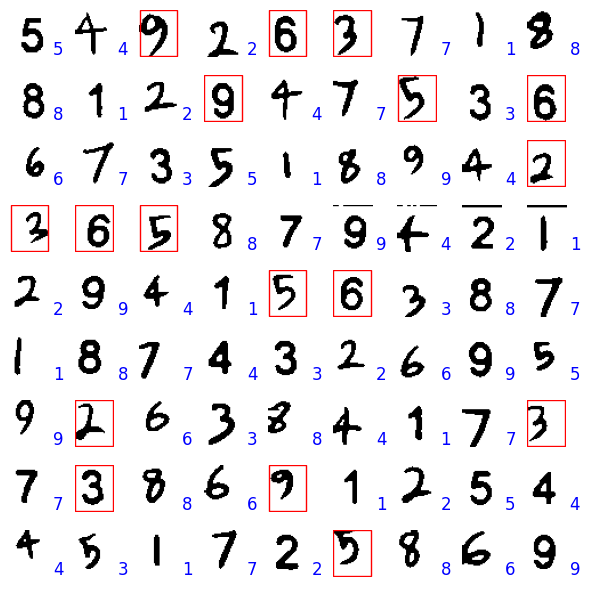

5 4 _ 2 _ _ 7 1 8
8 1 2 _ 4 7 _ 3 _
6 7 3 5 1 8 9 4 _
_ _ _ 8 7 9 4 2 1
2 9 4 1 _ _ 3 8 7
1 8 7 4 3 2 6 9 5
9 _ 6 3 8 4 1 7 _
7 _ 8 6 _ 1 2 5 4
4 3 1 7 2 _ 8 6 9

Valid Sudoku? True


In [92]:
image_test = load_sudoku_image("sudoku/3.jpg")
sudoku_numbers_test = read_sudoku_from_image(image_test, None, 0.75)
for row in sudoku_numbers_test:
    print(" ".join(row))
print("\nValid Sudoku?" , is_valid_sudoku(sudoku_numbers_test))

## Test 3

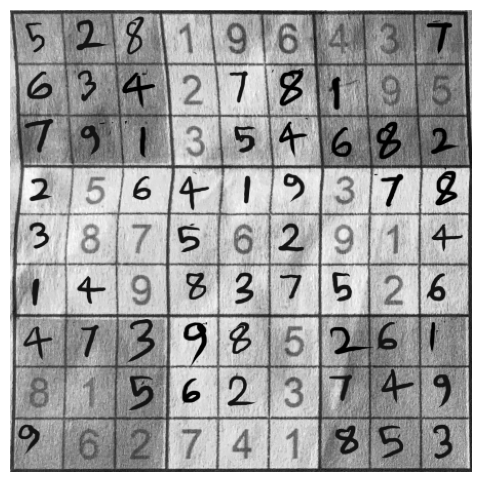

undetected = 22


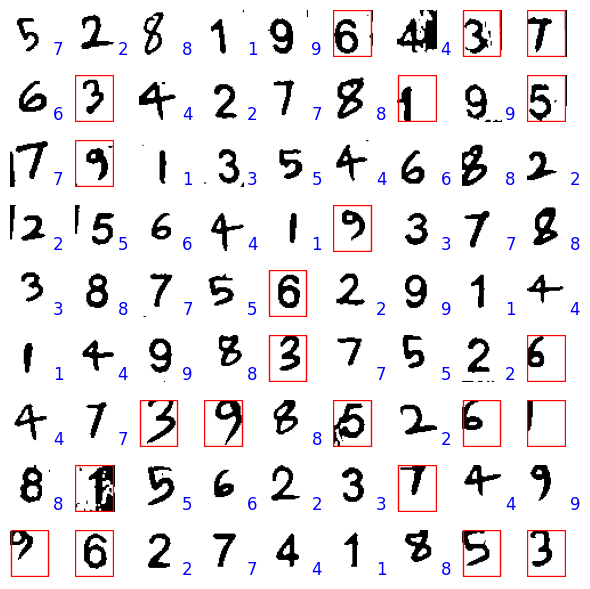

7 2 8 1 9 _ 4 _ _
6 _ 4 2 7 8 _ 9 _
7 _ 1 3 5 4 6 8 2
2 5 6 4 1 _ 3 7 8
3 8 7 5 _ 2 9 1 4
1 4 9 8 _ 7 5 2 _
4 7 _ _ 8 _ 2 _ _
8 _ 5 6 2 3 _ 4 9
_ _ 2 7 4 1 8 _ _

Valid Sudoku? False


In [91]:
image_test = load_sudoku_image("sudoku/4.jpg")
sudoku_numbers_test = read_sudoku_from_image(image_test, None, 0.75)
for row in sudoku_numbers_test:
    print(" ".join(row))
print("\nValid Sudoku?" , is_valid_sudoku(sudoku_numbers_test))

## Test 4

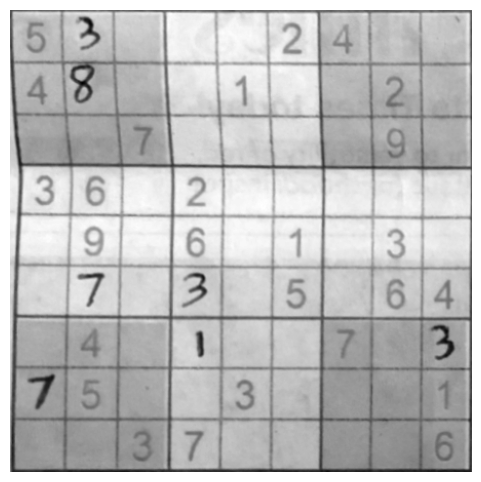

undetected = 54


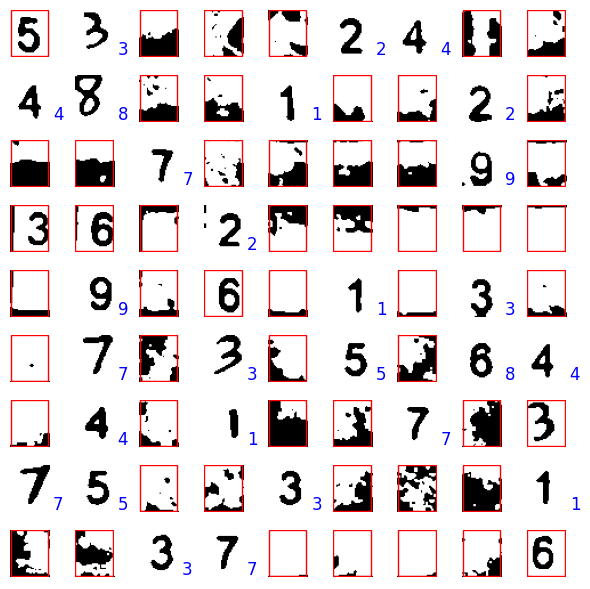

_ 3 _ _ _ 2 4 _ _
4 8 _ _ 1 _ _ 2 _
_ _ 7 _ _ _ _ 9 _
_ _ _ 2 _ _ _ _ _
_ 9 _ _ _ 1 _ 3 _
_ 7 _ 3 _ 5 _ 8 4
_ 4 _ 1 _ _ 7 _ _
7 5 _ _ 3 _ _ _ 1
_ _ 3 7 _ _ _ _ _

Valid Sudoku? True


In [90]:
image_test = load_sudoku_image("sudoku/5.jpg")
sudoku_numbers_test = read_sudoku_from_image(image_test, None, 0.75)
for row in sudoku_numbers_test:
    print(" ".join(row))
print("\nValid Sudoku?" , is_valid_sudoku(sudoku_numbers_test))